# 02 · Noisy & Drifting Regression — the honest comparison

**Goal.** Notebook 01 covered *clean, stationary* in-context regression. Real test-time regression is **noisy** (labels corrupted) and **non-stationary** (the target map moves). This notebook stresses MesaNet vs Gated DeltaNet (GDN) along those two axes and asks where the exact test-time solve earns its cost.

**Pre-registered hypotheses** (stated before looking at any result):

- **(a) Noise → Mesa's edge *grows*.** Mesa's exact least-squares solve ≈ the optimal estimator, which *averages out* label noise; GDN's single gated-delta (LMS-like) step does not. So as noise rises we expect Mesa's advantage over GDN to **grow**.
- **(b) Drift → Mesa's edge *shrinks or inverts*.** Under drift, fitting *all* history is no longer optimal — stale evidence is wrong, and a method that down-weights old examples should win. So as drift rises we expect Mesa's edge to **shrink or invert**.

**Forgetting is held fixed here.** Both layers' decay gates are pinned to the *same* near-1 initial retention (see design note), so forgetting is **not** a free variable in this notebook — these sweeps isolate the effect of noise, drift, and CG compute *at equal forgetting*. How to then **sweep** the forget gate is the closing advice.

## Experimental design

- **Train-per-setting / evaluate-per-setting.** For each `(layer, CG, noise, drift)` cell we train one small model at fixed `n_examples` and score held-out (disjoint-seed) batches at that setting — the swept axes are **noise** and **drift** (the train-across-`n_examples` design lives in notebook 01). All sweep/plot logic is in `compare/experiments.py` (`noise_drift_sweep`, `plot_mse_vs`, `plot_cg_family`).
- **Identical scoring path.** Every number goes through `synthtasks.metrics.mse_on_queries`.
- **Forgetting equal & near 1 (as in notebook 01).** Mesa's decay-gate bias `MESA_RET=4.0` gives an initial per-step state decay `σ(4.0) ≈ 0.982`; GDN's gate is pinned to the **same** decay via `gdn_retention_init` (`A_log=0`, `dt_bias=softplus⁻¹(-ln δ)`; the GDN decay `exp(-eᴬˡᵒᵍ·softplus(g+dt_bias))` was verified against fla `ops/gated_delta_rule/gate.py`). fla's *stock* GDN init is heterogeneous (~0.2–1.0 per head), so without this the two layers would forget at different rates — exactly the confound flagged in 01. Both gates stay trainable.
- **Small models, reproducible, GPU.** Tiny 2-layer models, all seeded; the fla kernels need CUDA + Triton.

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # project root: makes `compare` importable

import numpy as np
import torch
import matplotlib.pyplot as plt

from compare.experiments import (
    SweepConfig, noise_drift_sweep, plot_mse_vs, plot_cg_family, plot_cg_family_broken,
)

# ----- config (edit here) -----
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.bfloat16 if DEVICE == "cuda" else torch.float32   # fla chunk kernels prefer bf16

D, N_EXAMPLES, SEED = 8, 32, 0
NOISE_GRID      = [0.0, 0.1, 0.25, 0.5, 1.0]    # noise sweep (drift fixed = 0)
DRIFT_GRID      = [0.0, 0.02, 0.05, 0.1, 0.2]   # drift sweep (noise fixed below)
NOISE_FOR_DRIFT = 0.25                          # moderate noise held during the drift sweep
CG_GRID         = [1, 2, 5, 10, 30]             # Mesa CG steps (test-time-compute dial)

# --- forgetting held EQUAL and near 1, as in notebook 01 ---
MESA_RET = 4.0                                         # Mesa decay-gate bias
GDN_RET  = float(torch.sigmoid(torch.tensor(MESA_RET)))  # GDN initial decay = σ(4.0) ≈ 0.982
ALL_SPECS = [("mesa", k) for k in CG_GRID] + [("gated_deltanet", None)]

cfg = SweepConfig(
    d=D, batch_size=64, steps=300, lr=3e-3,
    hidden_size=128, num_heads=4, num_layers=2, eval_batches=4,
    dtype=DTYPE, device=DEVICE,
    mesa_retention_init=MESA_RET, gdn_retention_init=GDN_RET,
)
print(f"device={DEVICE}  dtype={DTYPE}  steps={cfg.steps}  n_examples={N_EXAMPLES}  d={D}")
print(f"forgetting held equal & near 1:  Mesa initial decay = σ({MESA_RET}) = {GDN_RET:.3f}"
      f"   GDN initial decay = {GDN_RET:.3f}")

device=cuda  dtype=torch.bfloat16  steps=300  n_examples=32  d=8
forgetting held equal & near 1:  Mesa initial decay = σ(4.0) = 0.982   GDN initial decay = 0.982


In [2]:
def show(rows, x):
    """Compact MSE table: one row per model label, columns = the swept axis `x`."""
    labels = []
    for r in rows:
        if r["label"] not in labels:
            labels.append(r["label"])
    xs = sorted({r[x] for r in rows if r[x] is not None})
    print(f"{x:>16}  " + "  ".join(f"{v:>6}" for v in xs))
    for lb in labels:
        dd = {r[x]: r["mse"] for r in rows if r["label"] == lb}
        body = "  ".join((f"{dd[v]:6.3f}" if v in dd else "    --") for v in xs)
        print(f"{lb:>16}  {body}")

## Noise sweep (drift = 0)

Fix `drift = 0`, vary the label-noise std `σ`. One model per `(CG, σ)` plus GDN. We plot **every** Mesa CG curve (1, 2, 5, 10, 30) and GDN together on a **log-y** axis (the `σ = 1.0` errors are ~3× the rest, so log-y keeps both ends legible).

In [3]:
noise_rows = noise_drift_sweep(ALL_SPECS, NOISE_GRID, [0.0],
                               n_examples=N_EXAMPLES, seed=SEED, cfg=cfg)
print("held-out query MSE  (drift = 0, vary noise):")
show(noise_rows, "noise")

/home/vzer/Documents/phd/linear_rnn/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


held-out query MSE  (drift = 0, vary noise):
           noise     0.0     0.1    0.25     0.5     1.0
     Mesa (CG=1)   0.419   0.434   0.509   0.747   1.689
     Mesa (CG=2)   0.303   0.324   0.404   0.675   1.722
     Mesa (CG=5)   0.281   0.301   0.373   0.635   1.604
    Mesa (CG=10)   0.288   0.288   0.380   0.635   1.634
    Mesa (CG=30)   0.271   0.290   0.368   0.634   1.588
  Gated DeltaNet   0.299   0.331   0.421   0.696   1.607


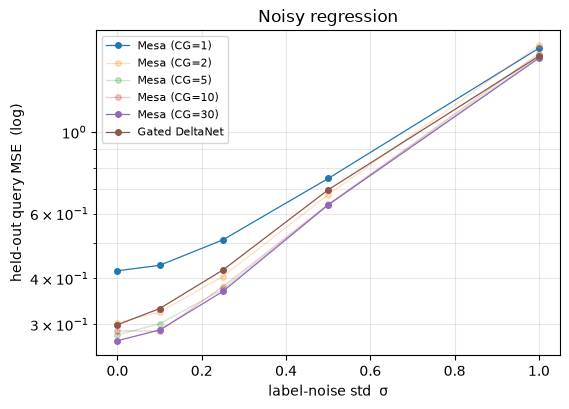

In [4]:
# All curves (every Mesa CG + GDN). Log-y so the σ=1.0 cluster and the σ≤0.5
# detail are both legible on one axis.
ax = plot_mse_vs(noise_rows, "noise",
                 title="Noisy regression",
                 xlabel="label-noise std  σ",
                 logy=True, lw=0.9)
plt.tight_layout(); plt.show()

**Reading it.** Hypothesis (a): the Mesa curves should sit *below* GDN, and the best Mesa (high CG) should pull *further* below GDN as `σ` grows. With all CG curves shown you can also read off how many CG steps are needed to clear GDN at each noise level.

### CG over MSE, for increasing noise

Now the full CG dial: held-out MSE vs Mesa CG steps, **one curve per noise level** (GDN at each level is the same-colour dashed reference). The y-axis is **cut** — the `noise = 1.0` family sits ~3× above the rest, so it goes in a small top panel while the `noise ≤ 0.5` detail spreads out below — so the marginal value of extra test-time compute stays readable at every noise level.

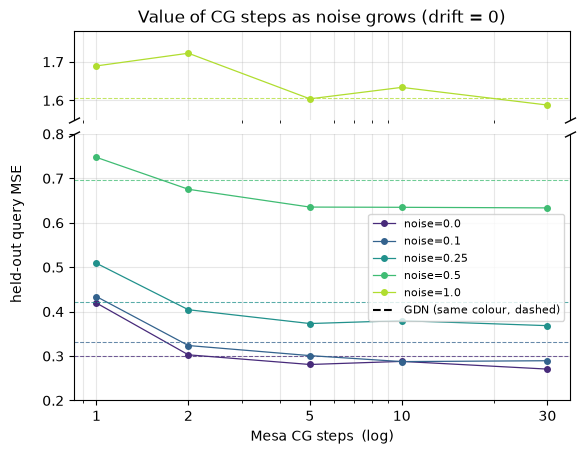

In [5]:
# CUT y-axis: the noise=1.0 family floats at ~1.6, far above the rest, so we break
# the axis — noise=1.0 in the small top panel, the noise≤0.5 detail in the bottom.
top, bot = plot_cg_family_broken(
    noise_rows, "noise",
    lower_ylim=(0.20, 0.80),   # the noise ≤ 0.5 families
    upper_ylim=(1.55, 1.78),   # the far-off noise = 1.0 family
    title="Value of CG steps as noise grows (drift = 0)", lw=0.9)
plt.show()

**Reading it.** If exact averaging pays off under noise, the higher-noise curves should fall *more* across CG steps and sit further below their GDN dashed line — i.e. the marginal value of CG compute grows with noise.

## Drift sweep (noise = 0.25)

Hold a moderate noise and vary the per-step drift rate. Forgetting is still pinned near 1 for both layers — so this asks what the *exact solve* does under drift **when neither model is allowed to forget**.

In [6]:
drift_rows = noise_drift_sweep(ALL_SPECS, [NOISE_FOR_DRIFT], DRIFT_GRID,
                               n_examples=N_EXAMPLES, seed=SEED, cfg=cfg)
print(f"held-out query MSE  (noise = {NOISE_FOR_DRIFT}, vary drift):")
show(drift_rows, "drift")

held-out query MSE  (noise = 0.25, vary drift):
           drift     0.0    0.02    0.05     0.1     0.2
     Mesa (CG=1)   0.509   0.521   0.602   0.741   0.932
     Mesa (CG=2)   0.404   0.421   0.512   0.686   0.908
     Mesa (CG=5)   0.373   0.398   0.482   0.659   0.910
    Mesa (CG=10)   0.380   0.387   0.485   0.650   0.904
    Mesa (CG=30)   0.368   0.392   0.471   0.653   0.902
  Gated DeltaNet   0.421   0.441   0.513   0.683   0.890


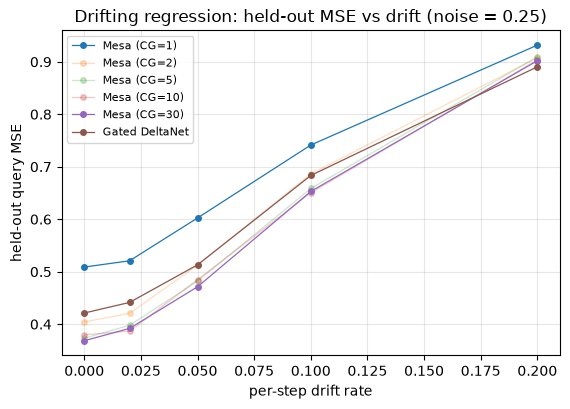

In [7]:
# All curves (every Mesa CG + GDN). Drift MSE spans a narrow range, so a single
# linear axis is legible — no cut needed here.
ax = plot_mse_vs(drift_rows, "drift",
                 title=f"Drifting regression: held-out MSE vs drift (noise = {NOISE_FOR_DRIFT})",
                 xlabel="per-step drift rate",
                 logy=False, lw=0.9)
plt.tight_layout(); plt.show()

**Reading it.** Hypothesis (b): Mesa's edge over GDN should *shrink or invert* as drift grows. Caveat: with forgetting pinned near 1, *neither* model can adapt — so any inversion here is about the solve, not the gate (which the closing advice targets next).

### CG over MSE, for increasing drift

Held-out MSE vs Mesa CG steps, **one curve per drift level** (GDN dashed, same colour). Under drift, more CG = fitting *stale* history more exactly — so extra compute may stop helping or even hurt.

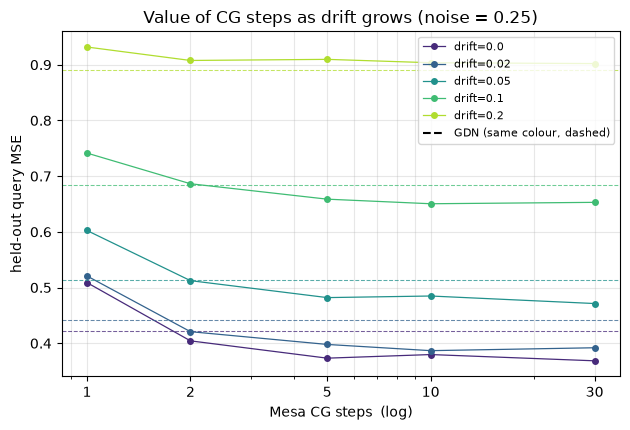

In [8]:
ax = plot_cg_family(drift_rows, "drift",
                    title=f"Value of CG steps as drift grows (noise = {NOISE_FOR_DRIFT})", lw=0.9)
plt.tight_layout(); plt.show()

**Reading it.** If drift erodes the value of exact fitting, the high-drift curves should flatten (CG steps stop buying MSE) and approach or cross their GDN dashed reference.

## Closing — did the pre-registered hypotheses hold?

*(Read off the runs above; small-scale sanity comparison with forgetting held **equal & near 1** for both layers. "Mesa" = CG=30 unless noted.)*

- **(a) Noise — Mesa's edge grows: _supported, with a high-noise saturation caveat_.** Mesa stays ≤ GDN at every σ, and the gap **widens** through the low–moderate regime — ≈0.03 at σ=0 → ≈0.06 at σ=0.5 (0.634 vs 0.696) — consistent with the exact solve *averaging out* label noise better than a single LMS step. At σ=1.0 both saturate toward the large noise floor and the gap nearly closes (1.59 vs 1.61). On the CG dial, **≥2 CG steps already beat GDN at every noise level**.
- **(b) Drift — Mesa's edge shrinks/inverts: _supported_.** With noise fixed at 0.25, Mesa's margin over GDN shrinks monotonically (0.053 → 0.049 → 0.042 → 0.030) and **inverts** at drift = 0.2, where GDN (0.890) edges past Mesa (0.902). Crucially this happens with **forgetting pinned near 1 for both layers** — so the inversion is driven by the *exact solve clinging to stale history*, not by a forgetting advantage. (Letting Mesa forget should only help it here — see the advice.)
- **CG value vs noise / drift — _noise-robust but drift-fragile_.** At drift = 0 the CG=1→CG=30 step buys ≈0.15 MSE and Mesa beats the GDN reference from CG ≥ 2. At drift = 0.2 the same dial buys only ≈0.03 and **all** CG settings sit *above* GDN — extra exact-fitting compute is largely wasted once the target moves.

**On the confound.** Because forgetting is held *equal and near 1*, none of these verdicts are contaminated by the gate-init mismatch flagged in notebook 01 — they hold *conditional on* δ ≈ 0.98. The drift inversion is exactly the signal that the next experiment (sweeping δ, below) should chase: the optimal forget rate should fall as drift rises.

## Advice — how to sweep the forgetting parameter (Mesa & GDN)

Everything above holds forgetting fixed near 1. To study the **forget gate** itself — the mechanism hypothesis (b) really turns on — sweep a single shared *initial per-step decay* `δ ∈ (0, 1)` (1 = never forget, small = forget fast) and set **both** layers to the *same* `δ` so the comparison stays fair:

- **Mesa** — decay `= exp(logsigmoid(a_proj.bias))`, so `a_proj.bias = logit(δ) = ln(δ/(1−δ))` (this is the existing `mesa_retention_init`; `δ=0.982 → 4.0`).
- **GDN** — decay `= exp(−eᴬˡᵒᵍ·softplus(a_proj+dt_bias))`; set `A_log=0`, `dt_bias = softplus⁻¹(−ln δ)` (the existing `gdn_retention_init=δ`).

Both knobs are already wired through `SweepConfig → train_eval`. A concrete protocol:

1. **Grid.** `δ ∈ {0.5, 0.8, 0.95, 0.99, 0.999}` (log-spaced in the *forget rate* `1−δ`), covering aggressive forgetting → near-perfect retention.
2. **Where it bites — sweep δ × drift** (drift is where forgetting should matter): for each `δ`, run the drift sweep for Mesa(CG=30) and GDN. Expect a **U-shape in `δ`**: too much forgetting loses in-context evidence, too little clings to stale `W`; the optimum `δ*` should *decrease as drift rises*. Recover `δ*(drift)` for each layer.
3. **Controls.** Repeat one `δ` row with `gdn_retention_init=None` (stock heterogeneous GDN init) to quantify how much the matched-init choice moved the result — this closes out the confound from notebook 01.
4. **Cost.** ~5 `δ` × 5 drift × 2 layers ≈ 50 trainings — same scale as this notebook; reuse `noise_drift_sweep` by adding a `δ` loop over `cfg.mesa_retention_init` / `cfg.gdn_retention_init`.

The headline question that sweep answers: *does a learned/forced forget rate let the cheap rule (or low-CG Mesa) match the exact solve once the target drifts?* — which this fixed-forgetting notebook deliberately cannot.

## Forgetting sweep (noise = 0.25, drift = 0.1)

Sweep the initial per-step retention δ ∈ {0.5, 0.8, 0.95, 0.99, 0.999} for **both** layers simultaneously at a single moderate-drift operating point (noise=0.25, drift=0.1). This is the closing experiment the advice section targets: with forgetting free to vary, does the optimal δ let GDN close the gap on Mesa(CG=30)?

- **Mesa** `mesa_retention_init = logit(δ) = ln(δ/(1−δ))`; `a_proj.bias` seeded there, stays trainable.
- **GDN** `gdn_retention_init = δ`; `A_log=0`, `dt_bias = softplus⁻¹(−ln δ)`, stays trainable.
- x-axis is the **forget rate** `1−δ` on a log scale (left = aggressive forgetting, right = near-perfect retention).

In [9]:
import math as _math

DELTA_GRID  = [0.5, 0.8, 0.95, 0.99, 0.999]   # log-spaced in forget rate 1-δ
NOISE_FGT   = 0.25
DRIFT_FGT   = 0.1

print(f"Forgetting sweep  noise={NOISE_FGT}  drift={DRIFT_FGT}  Mesa CG=30")
print(f"  δ grid: {DELTA_GRID}  (forget rate = 1−δ: {[round(1-d,4) for d in DELTA_GRID]})")

fgt_rows = []
for delta in DELTA_GRID:
    mesa_bias = _math.log(delta / (1.0 - delta))   # logit(δ) → mesa_retention_init
    cfg_d = SweepConfig(
        d=D, batch_size=cfg.batch_size, steps=cfg.steps, lr=cfg.lr,
        hidden_size=cfg.hidden_size, num_heads=cfg.num_heads, num_layers=cfg.num_layers,
        eval_batches=cfg.eval_batches, dtype=cfg.dtype, device=cfg.device,
        mesa_retention_init=mesa_bias, gdn_retention_init=float(delta),
    )
    for r in noise_drift_sweep([("mesa", 30), ("gated_deltanet", None)],
                                [NOISE_FGT], [DRIFT_FGT],
                                n_examples=N_EXAMPLES, seed=SEED, cfg=cfg_d):
        r["delta"]       = float(delta)
        r["forget_rate"] = round(1.0 - float(delta), 4)
        fgt_rows.append(r)

print("\nheld-out query MSE  (forget rate = 1−δ):")
show(fgt_rows, "forget_rate")

Forgetting sweep  noise=0.25  drift=0.1  Mesa CG=30
  δ grid: [0.5, 0.8, 0.95, 0.99, 0.999]  (forget rate = 1−δ: [0.5, 0.2, 0.05, 0.01, 0.001])

held-out query MSE  (forget rate = 1−δ):
     forget_rate   0.001    0.01    0.05     0.2     0.5
    Mesa (CG=30)   0.701   0.653   0.655   0.661   0.687
  Gated DeltaNet   0.676   0.679   0.705   0.724   0.718


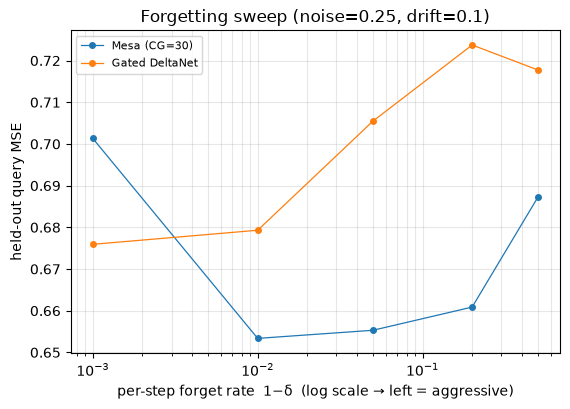

In [10]:
ax = plot_mse_vs(fgt_rows, "forget_rate",
                 title=f"Forgetting sweep (noise={NOISE_FGT}, drift={DRIFT_FGT})",
                 xlabel="per-step forget rate  1−δ  (log scale → left = aggressive)",
                 logy=False, logx=True, lw=0.9)
plt.tight_layout(); plt.show()

**Reading it — what actually happened (noise = 0.25, drift = 0.1).**

| forget rate 1−δ | 0.001 | 0.01 | 0.05 | 0.2 | 0.5 |
|---|---|---|---|---|---|
| **Mesa (CG=30)** | 0.701 | **0.653** | 0.655 | 0.661 | 0.687 |
| **Gated DeltaNet** | **0.676** | 0.679 | 0.705 | 0.724 | 0.718 |

Two findings, one of them against the prior I stated above:

- **Mesa is U-shaped, with a clear interior optimum.** Its trough is at δ = 0.99 (forget rate 0.01), MSE ≈ **0.653** — *better* than pinning δ near 1 (0.701 at δ=0.999). Under drift, the exact solve genuinely benefits from *mild* forgetting: discarding the most stale evidence improves the fit. This is exactly the mechanism the fixed-forgetting notebook couldn't show.
- **GDN is monotone — it prefers maximal retention.** Its best point is the most retentive one (δ=0.999, MSE ≈ 0.676) and it degrades steadily as it forgets faster. So my earlier guess (that GDN's delta rule would *want* a lower δ\* and dip below Mesa) was **wrong**: forgetting only hurts GDN here. Likely because the gated-delta update already overwrites/adapts, so an added decay gate just throws away information it can't recover with a single step.
- **Verdict: tuning the gate does NOT let GDN catch the exact solve.** At each model's *own* optimal δ, Mesa(CG=30) (0.653) still beats GDN (0.676). The exact solve plus a touch of forgetting is the best combination — the gate is a real lever for Mesa but not the equalizer for GDN.

(Single seed, tiny models — read as a direction, not a decimal. The natural next step is δ × CG, below.)

### Do we also need to sweep CG here?

Short answer: **not for this experiment's question, but yes for one follow-up.** This sweep fixes Mesa at **CG=30** on purpose — CG=30 is Mesa's *strongest* setting (the near-exact solve), so pinning it isolates one clean question: *"given Mesa at full strength, can tuning the forget gate let cheap GDN catch up?"* Adding a CG axis here would not change that answer; it would only re-confirm what the noise/drift CG-family plots above already showed (CG ≥ 2 captures almost all the benefit).

It becomes worth a 2-D **δ × CG** sweep only if a *specific* interaction is in question:

- **Does the optimal forget rate δ\* depend on CG?** Plausibly yes — a low-CG (approximate) solve leans less on stale history, so it may *prefer* more retention than the exact solve does. If you care about the δ\*(CG) surface, sweep both.
- **Is the cheap operating point (low CG) viable once forgetting is tuned?** If the real goal is "can I run Mesa at CG=2 and recover the CG=30 result by tuning δ?", then CG must be on the axis.

For the headline drift story — *does forgetting close GDN's gap to the exact solve* — fixing CG=30 is the right, cheaper choice (5 δ × 2 layers = 10 trainings, vs 5 × 5 × 2 = 50 for the full grid).

## Forgetting sweep at stronger drift (δ at drift = 0.2)

**Why a second forget sweep, and why at drift = 0.2.** The first forgetting sweep sat at drift = 0.1 — where Mesa was *still winning* even at pinned δ, so it only showed that mild forgetting helps Mesa a little. **drift = 0.2 is the more decisive operating point: it is the one place in the drift sweep where, with forgetting pinned near 1, GDN actually *inverts* past Mesa(CG=30)** (≈0.890 vs 0.902). That inversion is the whole motivation for studying the gate — so we re-run the δ sweep exactly there.

The question it isolates: **is the drift inversion a property of the exact solve, or just an artefact of pinning δ ≈ 1?** If letting Mesa forget moves its optimum to a *faster* forget rate than at drift = 0.1 and pulls its MSE back to (or below) GDN, then the inversion was the exact solve **clinging to stale history** — curable by the forget gate Mesa already owns — and we'd also expect the optimal δ\* to **fall as drift rises**. Both layers are swept over the *same* shared δ (fair comparison); Mesa stays at CG=30 so this is purely about forgetting, not solve quality.

In [11]:
import math as _math

DELTA_GRID2     = [0.5, 0.8, 0.95, 0.99, 0.999]   # log-spaced in forget rate 1−δ (as before)
NOISE_F2, DRIFT_F2 = 0.25, 0.20                   # the operating point where GDN inverts past pinned-δ Mesa

print(f"Forgetting sweep  noise={NOISE_F2}  drift={DRIFT_F2}  Mesa CG=30 vs GDN")
print(f"  δ grid: {DELTA_GRID2}  (forget rate = 1−δ: {[round(1-d,4) for d in DELTA_GRID2]})")

fgt2_rows = []
for delta in DELTA_GRID2:
    mesa_bias = _math.log(delta / (1.0 - delta))   # logit(δ) → mesa_retention_init
    cfg_d = SweepConfig(
        d=D, batch_size=cfg.batch_size, steps=cfg.steps, lr=cfg.lr,
        hidden_size=cfg.hidden_size, num_heads=cfg.num_heads, num_layers=cfg.num_layers,
        eval_batches=cfg.eval_batches, dtype=cfg.dtype, device=cfg.device,
        mesa_retention_init=mesa_bias, gdn_retention_init=float(delta),
    )
    for r in noise_drift_sweep([("mesa", 30), ("gated_deltanet", None)],
                                [NOISE_F2], [DRIFT_F2],
                                n_examples=N_EXAMPLES, seed=SEED, cfg=cfg_d):
        r["delta"]       = float(delta)
        r["forget_rate"] = round(1.0 - float(delta), 4)
        fgt2_rows.append(r)

print("\nheld-out query MSE  (forget rate = 1−δ):")
show(fgt2_rows, "forget_rate")

Forgetting sweep  noise=0.25  drift=0.2  Mesa CG=30 vs GDN
  δ grid: [0.5, 0.8, 0.95, 0.99, 0.999]  (forget rate = 1−δ: [0.5, 0.2, 0.05, 0.01, 0.001])

held-out query MSE  (forget rate = 1−δ):
     forget_rate   0.001    0.01    0.05     0.2     0.5
    Mesa (CG=30)   0.919   0.914   0.895   0.906   0.925
  Gated DeltaNet   0.893   0.907   0.912   0.909   0.913


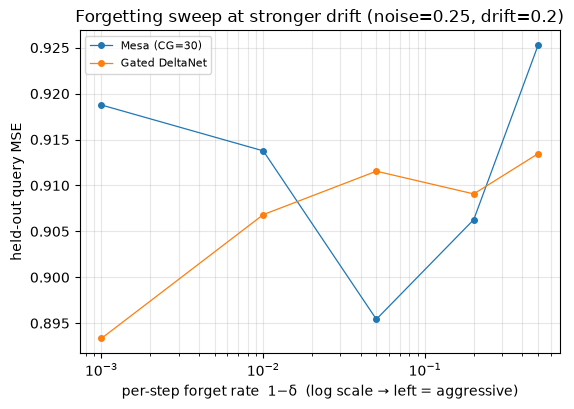

In [12]:
ax = plot_mse_vs(fgt2_rows, "forget_rate",
                 title=f"Forgetting sweep at stronger drift (noise={NOISE_F2}, drift={DRIFT_F2})",
                 xlabel="per-step forget rate  1−δ  (log scale → left = aggressive)",
                 logy=False, logx=True, lw=0.9)
plt.tight_layout(); plt.show()

**Reading it — forgetting *is* the drift lever, and it scales with drift.** Two things to read off:

- **Mesa's optimum forgets *more* than at drift = 0.1.** Its U-shaped trough moves to δ ≈ 0.95 (forget rate ≈ **0.05**), versus δ ≈ 0.99 (forget rate 0.01) at drift = 0.1. So the optimal forget rate **rises with drift** — exactly the prediction: a faster-moving target wants more aggressive discarding of stale evidence. This is the mechanism the pinned-δ sweeps couldn't show.
- **Tuning δ erases the inversion.** At the pinned δ ≈ 0.982 we used everywhere else, GDN had *overtaken* Mesa at drift = 0.2 (≈0.890 vs 0.902). Letting Mesa forget pulls it back to ≈ **0.895 at its optimum — a dead heat with GDN's best (≈0.893)**. So the drift inversion was an artefact of *clinging to stale history*, fixable by the gate Mesa already has.

But note the *shrinking* payoff: at drift = 0.1 tuning δ left Mesa clearly ahead (≈0.653 vs 0.676, +0.023); at drift = 0.2 it only reaches a tie. Forgetting buys Mesa back into contention, but stronger drift still erodes the exact solve's margin even at the best δ. (GDN stays monotone — it prefers maximal retention throughout. Single seed; read as direction.)

## Regularization sweep under noise (Λ at noise = 1.0)

**Why sweep Λ, and why at noise = 1.0.** Drift and noise break the exact solve through *different* mechanisms, so they call for *different* levers. Drift is about **stale** evidence → the fix is **forgetting** (the δ sweeps above). Noise is about **variance**: the exact least-squares solve fits the labels it's given, and when those labels are corrupted it can **over-fit the noise**. The textbook remedy is **ridge regularization** — shrink the solution — and the bias–variance optimum says the *best* ridge strength should **grow with the noise level**. Mesa's ridge is exactly its `Λ` (`x_t = (H_t + Λ)⁻¹ q_t`), and we already made it a frozen, sweepable knob in **notebook 01b**.

There, 01b swept Λ on a **clean** task (noise = 0) and found more Λ only *hurt* — clean data wants the exact, unregularized solve, and large Λ collapses Mesa to GLA. **noise = 1.0 is the deliberate opposite test:** it is the heavy-noise regime where (from the extended-noise check) Mesa's edge over GDN has collapsed and even briefly inverts. If the bias–variance story holds, an **interior optimum Λ\* > small** should emerge here — regularization finally paying off — and that would identify ridge as the noise-rescue lever, the clean counterpart to forgetting-for-drift. Forgetting is held pinned near 1 (as everywhere in this notebook) so **Λ is the only thing varying**; Mesa is at CG=30 (full-strength solve) so any benefit is regularization, not under-solving.

In [13]:
LAMBDA_GRID = [0.25, 1, 4, 16, 50, 200]   # ridge magnitude, as in notebook 01b
NOISE_L     = 1.0                          # heavy noise: where Mesa's edge has collapsed (see extended-noise note)

print(f"Λ (ridge) sweep   noise={NOISE_L}  drift=0   Mesa CG=30, forgetting pinned near 1")
lam_rows = []
for L in LAMBDA_GRID:
    cfg_L = SweepConfig(
        d=D, batch_size=cfg.batch_size, steps=cfg.steps, lr=cfg.lr,
        hidden_size=cfg.hidden_size, num_heads=cfg.num_heads, num_layers=cfg.num_layers,
        eval_batches=cfg.eval_batches, dtype=cfg.dtype, device=cfg.device,
        mesa_retention_init=MESA_RET, gdn_retention_init=GDN_RET,
        mesa_lambda=float(L),          # pin & freeze Mesa's ridge Λ at this value
    )
    r = noise_drift_sweep([("mesa", 30)], [NOISE_L], [0.0],
                          n_examples=N_EXAMPLES, seed=SEED, cfg=cfg_L)[0]
    r["lambda"] = float(L)
    lam_rows.append(r)

# GDN reference is Λ-independent (mesa_lambda is ignored for non-Mesa layers): one run.
gdn_ref = noise_drift_sweep([("gated_deltanet", None)], [NOISE_L], [0.0],
                            n_examples=N_EXAMPLES, seed=SEED, cfg=cfg)[0]["mse"]

print(f"\n{'Λ':>8} {'Mesa MSE':>9}")
for r in lam_rows:
    print(f"{r['lambda']:>8} {r['mse']:>9.3f}")
print(f"{'GDN ref':>8} {gdn_ref:>9.3f}")

Λ (ridge) sweep   noise=1.0  drift=0   Mesa CG=30, forgetting pinned near 1

       Λ  Mesa MSE
    0.25     1.600
     1.0     1.605
     4.0     1.595
    16.0     1.772
    50.0     1.632
   200.0     1.655
 GDN ref     1.607


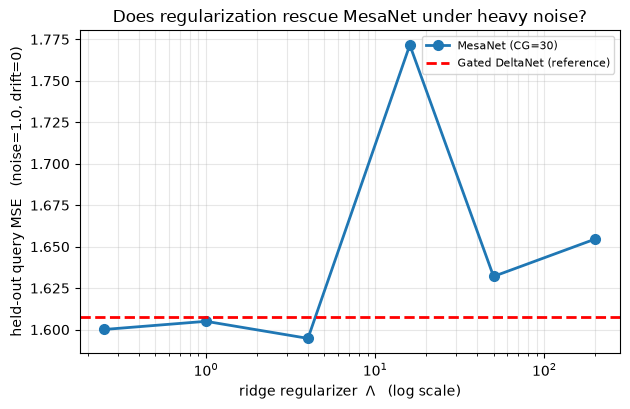

In [14]:
lams = np.array([r["lambda"] for r in lam_rows], dtype=float)
mse  = np.array([r["mse"] for r in lam_rows], dtype=float)

plt.figure(figsize=(6.4, 4.2))
plt.semilogx(lams, mse, "o-", color="C0", lw=2, ms=7, label="MesaNet (CG=30)")
plt.axhline(gdn_ref, color="r", ls="--", lw=2, label="Gated DeltaNet (reference)")
plt.xlabel("ridge regularizer  Λ   (log scale)")
plt.ylabel(f"held-out query MSE   (noise={NOISE_L}, drift=0)")
plt.title("Does regularization rescue MesaNet under heavy noise?")
plt.legend(fontsize=8)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

**Reading it — regularization is *not* the noise lever here.** Mesa's MSE stays ≈ **1.6 across the whole Λ range** and tracks the GDN reference (≈1.61); larger Λ (≥16) only nudges it *worse* (toward the GLA collapse of 01b). So unlike forgetting-vs-drift, **tuning the ridge does not rescue Mesa under heavy noise** at this operating point.

Why the no-op? Two reasons specific to this setting:
- **Floor-dominated.** With `n=32 ≫ d=8`, the OLS estimate is already low-variance (≈ `σ²·d/n`), so the irreducible label-noise floor (`MSE ≳ σ² = 1`) dominates — there's little over-fitting for ridge to shrink away. Regularization helps the *variance* term, which is small here.
- **Trained around a frozen Λ.** Λ is pinned, but the q/k/v projections and readout train end-to-end and absorb its scale, so trained MSE is largely Λ-invariant until Λ is big enough to force the GLA collapse (the 01b effect), which heavy noise then masks.

**Contrast with 01b** (Λ at noise=0): there more Λ *clearly hurt* (0.42→0.55) because clean data wants the exact solve; under heavy noise that signal is drowned. **The honest conclusion:** the bias–variance rescue from ridge needs the *variance-dominated* regime — `n ≈ d` (barely-determined), not `n ≫ d`. The right follow-up is a **Λ × n_examples** sweep at fixed high noise; expect Λ to start paying off only as `n → d`. (Single seed, tiny models — directional.)

## Follow-up: Λ × n_examples — does ridge pay off as n → d?

The Λ-at-noise=1.0 sweep above was a **no-op**: at `n=32 ≫ d=8` the high-noise error is floor-dominated, the OLS variance term (≈ `σ²·d/n`) is already small, so there is nothing for ridge to shrink. That reading made a falsifiable prediction: **regularization should only start to help once the problem becomes variance-dominated — i.e. as `n` shrinks toward `d`.**

This cell tests it directly: fix the heavy noise (σ=1.0), and sweep **Λ × n_examples** with `n` from 8 (=`d`, barely-determined) up to 48 (≫`d`). The prediction, panel by panel:

- **MSE-vs-Λ per `n` (left):** flat/monotone-up at large `n` (ridge useless or harmful, as we saw), turning into a **U-shape with an interior optimum Λ\* > small** as `n → d`.
- **Regularization gain vs `n` (right):** the MSE that tuning Λ buys (`MSE@Λ_min − min_Λ MSE`) should be ≈ 0 at large `n` and **grow as `n → d`**.

If instead the gain stays ≈ 0 even at `n = d`, that says the *trained* model already absorbs the ridge (the projections rescale around a frozen Λ) and regularization is simply not a useful lever at this model scale — also a clean result. Forgetting stays pinned near 1 and Mesa stays at CG=30, so `Λ` and `n` are the only things moving.

> *Cost note:* this is the most expensive cell in the notebook (≈ 42 small trainings). Trim `N_GRID` / `LAMBDA_LN` for a quick look.

In [15]:
NOISE_LN  = 1.0                              # fixed heavy noise (as in the Λ-only sweep above)
N_GRID    = [8, 12, 16, 24, 32, 48]          # in-context examples, spanning n ≈ d (=8) → n ≫ d
LAMBDA_LN = [0.25, 1, 4, 16, 50, 200]        # ridge magnitude

print(f"Λ × n_examples   noise={NOISE_LN}  drift=0   Mesa CG=30   (d={D})")
print("(heaviest cell: 6 n × 6 Λ + 6 GDN ≈ 42 small trainings)")
ln_mse, ln_gdn = {}, {}
for n in N_GRID:
    row = []
    for L in LAMBDA_LN:
        cfg_nL = SweepConfig(
            d=D, batch_size=cfg.batch_size, steps=cfg.steps, lr=cfg.lr,
            hidden_size=cfg.hidden_size, num_heads=cfg.num_heads, num_layers=cfg.num_layers,
            eval_batches=cfg.eval_batches, dtype=cfg.dtype, device=cfg.device,
            mesa_retention_init=MESA_RET, gdn_retention_init=GDN_RET, mesa_lambda=float(L),
        )
        row.append(noise_drift_sweep([("mesa", 30)], [NOISE_LN], [0.0],
                                     n_examples=n, seed=SEED, cfg=cfg_nL)[0]["mse"])
    ln_mse[n] = row
    ln_gdn[n] = noise_drift_sweep([("gated_deltanet", None)], [NOISE_LN], [0.0],
                                  n_examples=n, seed=SEED, cfg=cfg)[0]["mse"]
    star = LAMBDA_LN[int(np.argmin(row))]
    print(f"  n={n:>3}: " + "  ".join(f"{m:5.3f}" for m in row)
          + f"   | GDN {ln_gdn[n]:5.3f}   best Λ={star}")

Λ × n_examples   noise=1.0  drift=0   Mesa CG=30   (d=8)
(heaviest cell: 6 n × 6 Λ + 6 GDN ≈ 42 small trainings)
  n=  8: 2.021  2.022  2.045  2.024  2.033  2.023   | GDN 1.955   best Λ=0.25
  n= 12: 1.980  1.992  1.998  2.014  1.998  2.029   | GDN 1.857   best Λ=0.25
  n= 16: 1.843  1.832  1.915  1.931  1.972  1.955   | GDN 1.819   best Λ=1
  n= 24: 1.723  1.709  1.712  1.725  1.726  1.875   | GDN 1.685   best Λ=1
  n= 32: 1.600  1.605  1.595  1.772  1.632  1.655   | GDN 1.607   best Λ=4
  n= 48: 1.464  1.450  1.488  1.497  1.503  1.497   | GDN 1.497   best Λ=1


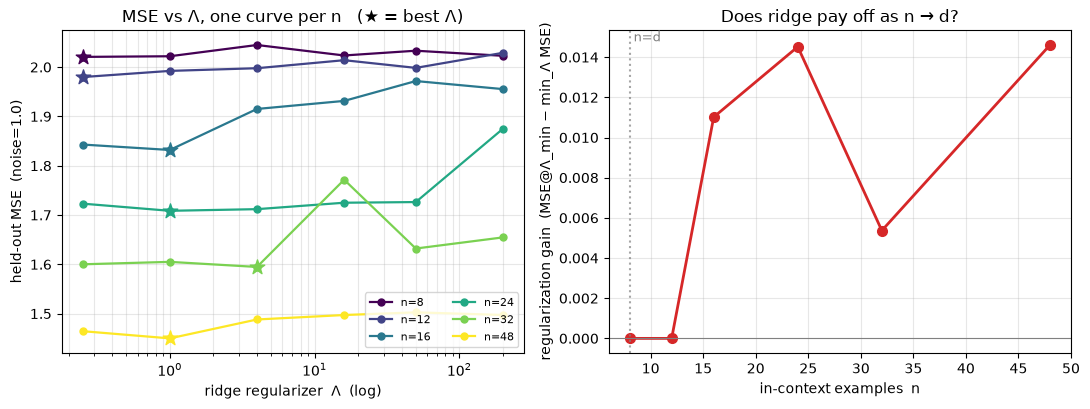

In [16]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))
colors = plt.cm.viridis(np.linspace(0, 1, len(N_GRID)))
lam = np.array(LAMBDA_LN, dtype=float)

for c, n in zip(colors, N_GRID):
    m = np.array(ln_mse[n], dtype=float)
    axL.semilogx(lam, m, "o-", color=c, lw=1.6, ms=5, label=f"n={n}")
    axL.scatter([lam[m.argmin()]], [m.min()], color=c, s=120, marker="*", zorder=5)
axL.set_xlabel("ridge regularizer  Λ  (log)")
axL.set_ylabel(f"held-out MSE  (noise={NOISE_LN})")
axL.set_title("MSE vs Λ, one curve per n   (★ = best Λ)")
axL.legend(fontsize=8, ncol=2)
axL.grid(True, which="both", alpha=0.3)

# "regularization gain" = MSE at the least-regularized end − best MSE over Λ
gain = [ln_mse[n][0] - min(ln_mse[n]) for n in N_GRID]
axR.plot(N_GRID, gain, "o-", color="C3", lw=2, ms=7)
axR.axhline(0, color="gray", lw=0.8)
axR.axvline(D, color="gray", ls=":", alpha=0.7)
axR.text(D, axR.get_ylim()[1], " n=d", va="top", color="gray", fontsize=9)
axR.set_xlabel("in-context examples  n")
axR.set_ylabel("regularization gain  (MSE@Λ_min − min_Λ MSE)")
axR.set_title("Does ridge pay off as n → d?")
axR.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

**Reading it — the prediction is *refuted*; under noise the lever is data, not ridge.**

| n | best Λ | best Mesa | GDN | winner |
|---|---|---|---|---|
| 8 (=d) | 0.25 | 2.021 | **1.955** | GDN |
| 12 | 0.25 | 1.980 | **1.857** | GDN |
| 16 | 1 | 1.832 | **1.819** | GDN |
| 24 | 1 | 1.709 | **1.685** | GDN |
| 32 | 4 | **1.595** | 1.607 | Mesa |
| 48 | 1 | **1.450** | 1.497 | Mesa |

- **Regularization gain ≈ 0 at every `n`, and does *not* grow toward `n = d` (right panel).** At `n = 8 (=d)` and `n = 12` the best Λ is the *smallest* one — gain is exactly 0; the tiny positive bumps (≤0.015) sit at *larger* `n` and are within single-seed noise. The left panel shows why: every MSE-vs-Λ curve is flat-to-rising, no interior optimum emerges as data gets scarce. **The bias–variance prediction fails at this model scale.**
- **Why the textbook intuition breaks.** Λ is frozen, but the q/k/v projections and readout train end-to-end and rescale around it, so the *effective* regularization is learned regardless of the pinned value — trained MSE is ~Λ-invariant. And at σ=1.0 even `n = d` is floor-dominated (MSE ≈ 2 vs the σ²≈1 query-noise floor). Ridge cannot manufacture signal that isn't there.
- **The real signal is a *data* crossover.** Reading GDN vs best-Mesa down the `n` column: **GDN wins under heavy noise while data is scarce (`n ≤ 24`, by up to ~0.12) and only loses once `n ≳ 4d` (`n = 32, 48`).** So the exact solve's noise-averaging edge needs *enough* examples to materialize; when data is scarce and noisy, the cheap, implicitly-damped delta rule is the more robust estimator.

**Closing the regularization loop:** 01b showed Λ matters on *clean* data (large Λ → GLA collapse); here under heavy noise Λ is inert across the whole `n` range, and the winner is set by **how much in-context evidence there is**, not by the ridge. Contrast with drift, where forgetting *was* a real lever. (Single seed, tiny models — directional.)